In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import pandas as pd # 

In [2]:
df = pd.read_csv('match_data_300_tourns_modified.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34521 entries, 0 to 34520
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player1                   34521 non-null  object 
 1   player2                   34521 non-null  object 
 2   best_of                   34521 non-null  int64  
 3   player1_elo               34521 non-null  int64  
 4   player2_elo               34521 non-null  int64  
 5   elo_match_win_rate        34521 non-null  float64
 6   elo_frame_win_rate        34521 non-null  float64
 7   p1_matches_played         34521 non-null  int64  
 8   p1_matches_won            34521 non-null  int64  
 9   p1_frames_played          34521 non-null  int64  
 10  p1_frames_won             34521 non-null  int64  
 11  p2_matches_played         34521 non-null  int64  
 12  p2_matches_won            34521 non-null  int64  
 13  p2_frames_played          34521 non-null  int64  
 14  p2_fra

In [4]:
from sklearn.metrics import mean_absolute_error

# Calculate MSE
y_true = df['win_percentage']
y_pred = df['elo_frame_win_rate']
elo_mse = mean_absolute_error(y_true, y_pred)

print("Elo Root Mean Squared Error:", elo_mse)

Elo Root Mean Squared Error: 0.21939344778504524


In [5]:
y_true = df['win_percentage']
y_pred = df['elo_frame_win_rate']

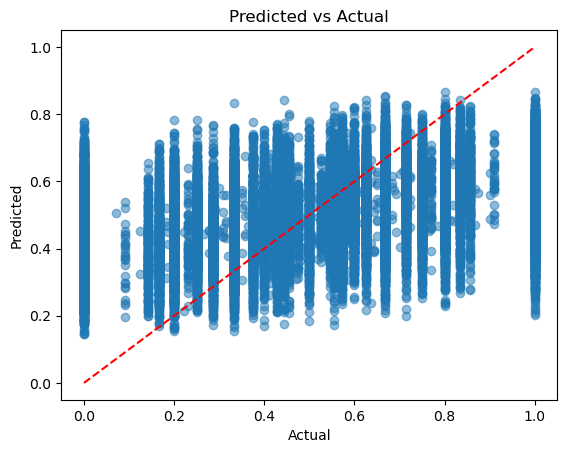

In [6]:
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show()


Elo win predictions typically range from around 0.18 to 0.8. However, in reality, there are matches where a player completely dominates and wins all the frames. Since Elo ratings always assign each player a nonzero chance of winning and all players have non-zero rating points, the predicted probabilities are never exactly 0 or 1. While this approach is generally suitable for sports predictions, it doesn't account for extreme outcomes, leading to some large prediction errors.

In [7]:
residuals = y_true-y_pred

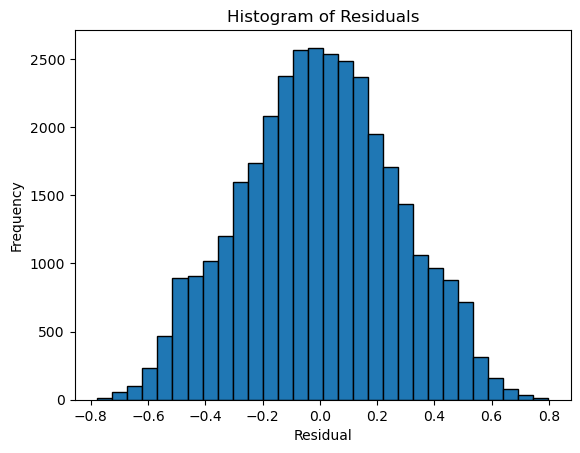

In [8]:
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()


#### Train test split

We divide our data into train and test split by keeping the last 20% of the data for testing our models at the end. The remaining 80% is used for traing and cross validation while training for hyperparameter tuning. We use mean absolute error (MAE) as the performance metic for the models.

As a first step, we apply the performance metric to evaluate the Elo-based predictions.

In [9]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, 
                                        test_size = 0.2,
                                        shuffle=False)


##### MAE on final test set
This step will be done for the other models only at the very end once we have done hyperparameter tuning with the rest of the data.

In [10]:
from sklearn.metrics import mean_absolute_error
y_test = df_test["win_percentage"]
y_pred = df_test["elo_frame_win_rate"]

rmse = mean_absolute_error(y_test, y_pred)
print(f"MAE for elo on test set:   {rmse:.4f}")

MAE for elo on test set:   0.2210


## 1. Explore the MAE (mean absolute error) by elo on different range of matches.

We plot the rolling average of correct prediction (i.e. prediction accuracy on certain range of matches). This is inspired by much lower prediction accuracy on the test set than on the training set during our first attempt of modeling. 

In [11]:
absolute_error = (df['elo_frame_win_rate']-df['win_percentage']).abs()

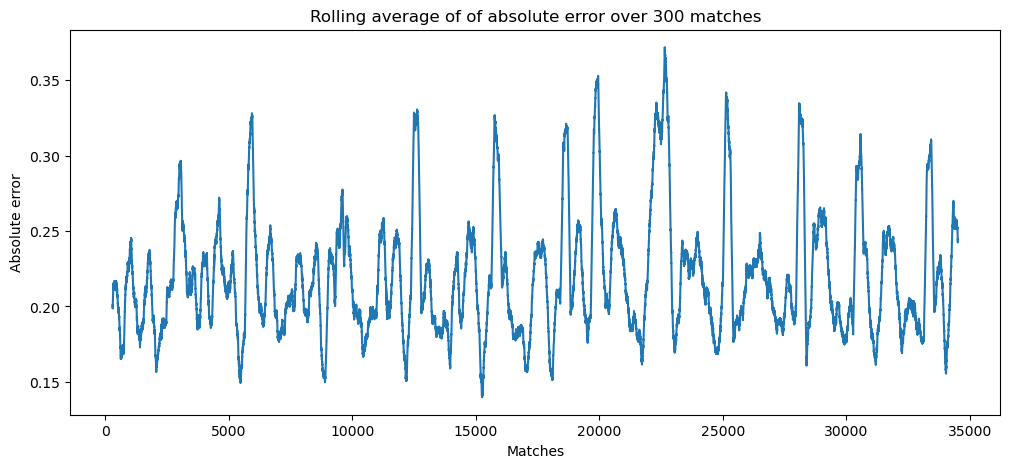

In [12]:
rolling_300 = absolute_error.rolling(window=300).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling_300)
plt.xlabel('Matches')
plt.ylabel('Absolute error')
plt.title('Rolling average of of absolute error over 300 matches')
plt.show()

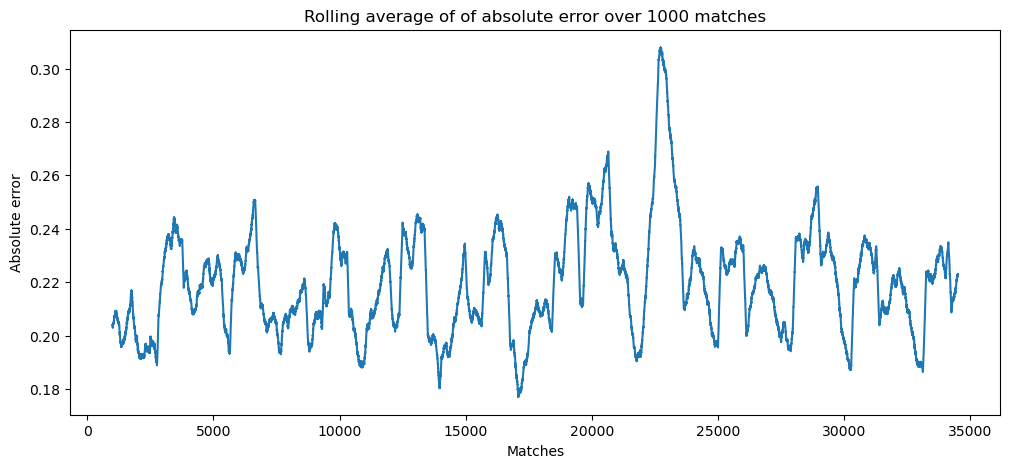

In [13]:
rolling_1k = absolute_error.rolling(window=1000).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling_1k)
plt.xlabel('Matches')
plt.ylabel('Absolute error')
plt.title('Rolling average of of absolute error over 1000 matches')
plt.show()

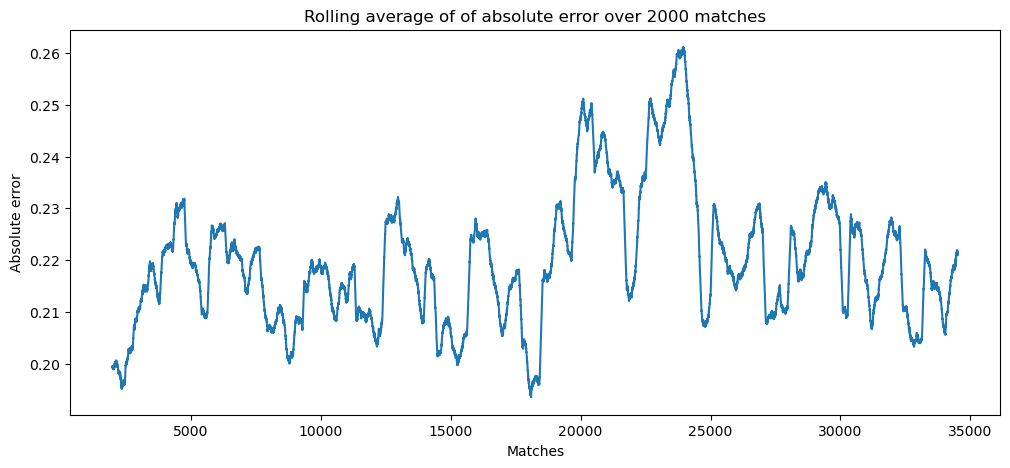

In [14]:
rolling_2k = absolute_error.rolling(window=2000).mean()
plt.figure(figsize = (12, 5))
plt.plot(rolling_2k)
plt.xlabel('Matches')
plt.ylabel('Absolute error')
plt.title('Rolling average of of absolute error over 2000 matches')
plt.show()

The performance fluctuate within a range of 0.04 in general except for for the matches between 20000 and 24000. We will investigate this match range.

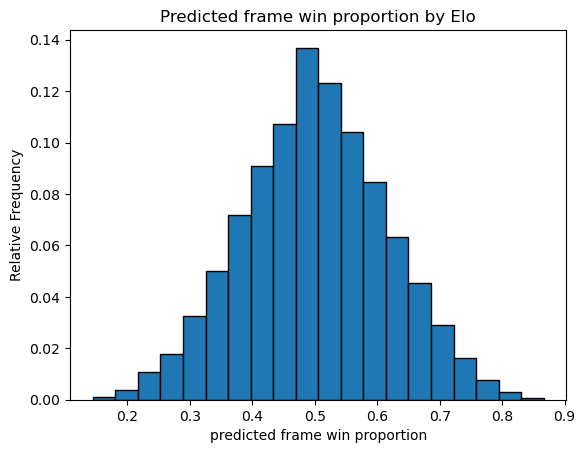

In [ ]:
import matplotlib.pyplot as plt

counts, bins, patches = plt.hist(df['elo_frame_win_rate'], bins=20, density=False)
relative_freq = counts / counts.sum()

plt.clf()

plt.bar(bins[:-1], relative_freq, width=np.diff(bins), edgecolor='black', align='edge')
plt.xlabel('predicted frame win proportion')
plt.ylabel('Relative Frequency')
plt.title('Predicted frame win proportion by Elo')
plt.show()

Elo predictions are normally distributed around 0.5. A prediction of a match where one player fully dominates, i.e win percentage of 0 or 1 is highly unlikely using elo. We next look at the actual win percentages on the three different subsets.

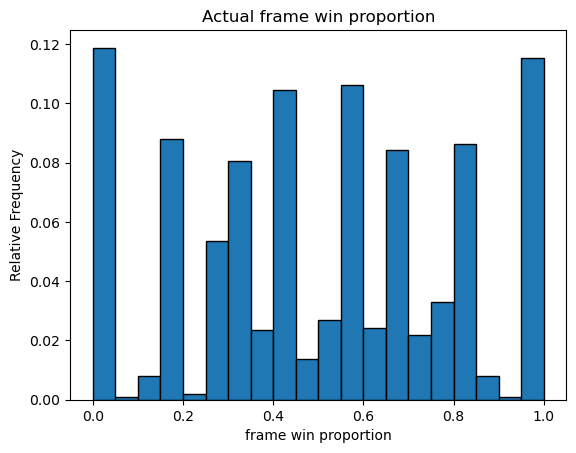

In [ ]:
counts, bins, patches = plt.hist(df['win_percentage'], bins=20, density=False)
relative_freq = counts / counts.sum()

plt.clf()

plt.bar(bins[:-1], relative_freq, width=np.diff(bins), edgecolor='black', align='edge')
plt.xlabel('frame win proportion')
plt.ylabel('Relative Frequency')

plt.savefig("proportion_hist.png", dpi=300, bbox_inches='tight')
plt.show()

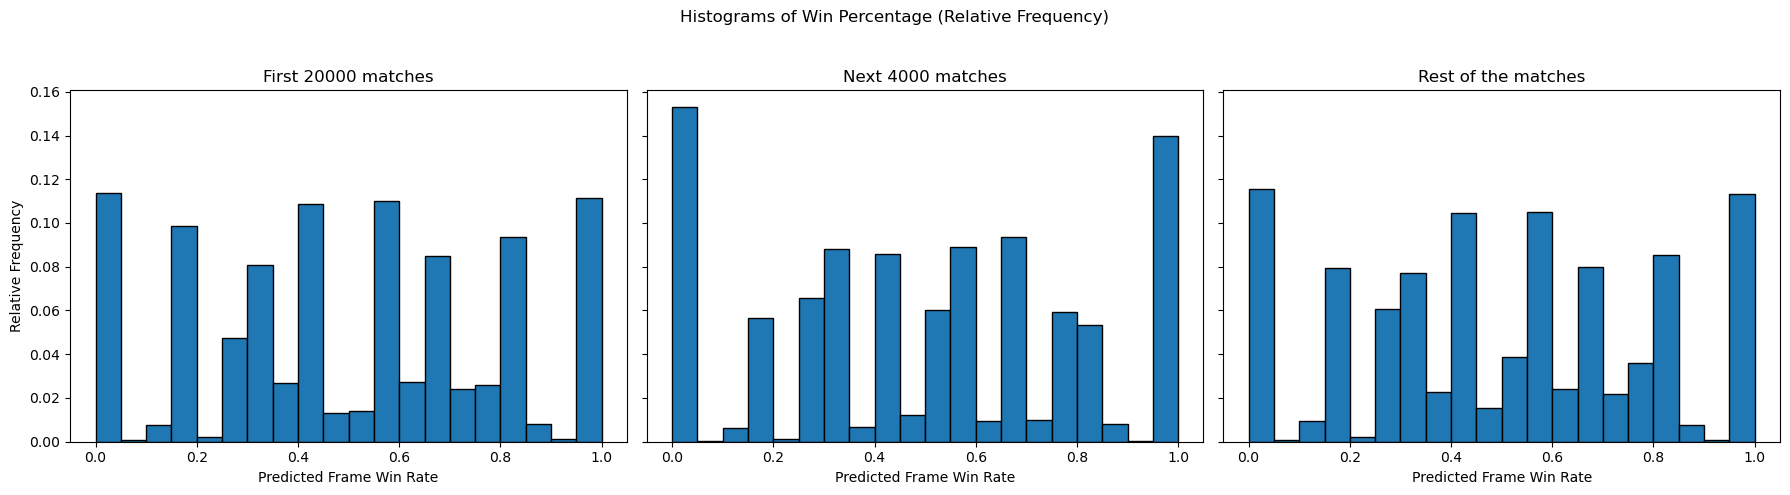

In [17]:
data_subset0 = df[:20000]
data_subset1 = df[20000:24000]
data_subset2 = df[24000:]

subset1 = data_subset0['win_percentage']
subset2 = data_subset1['win_percentage']
subset3 = data_subset2['win_percentage']

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

titles = ['First 20000 matches', 'Next 4000 matches', 'Rest of the matches']

for ax, data, title in zip(axs, [subset1, subset2, subset3], titles):
    counts, bins = np.histogram(data, bins=20, density=True)
    bin_width = bins[1] - bins[0]
    relative_freq = counts * bin_width

    ax.bar(bins[:-1], relative_freq, width=bin_width, edgecolor='black', align='edge')
    ax.set_xlabel('Predicted Frame Win Rate')
    ax.set_title(title)

axs[0].set_ylabel('Relative Frequency')

plt.suptitle('Histograms of Win Percentage (Relative Frequency)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

We focus on the more extreme cases, where the actual frame win percentage is 0-5% or 95-100%, on each plot above. There are more cases of a player fully dominating a match in the range of match number 20000 to 24000. These create larger error compared to the elo based predictions.